# Molecular dynamics: a recorded experiment

This notebook has already run. Its plots and particle trajectories are saved in
this page. Press **Play** under a particle view to explore the recorded motion;
no Python kernel or running simulation is needed for playback.

We use LJ reduced reference units: σ_ref = ε_ref = mass_ref = kB = 1.
Species parameters below are expressed relative to these common references.

The main settings are written out in each example so you can change them directly.
`timestep` is the integration step in reduced time; `steps * timestep` is the run duration.
`ensemble="nvt"` fixes the volume and uses a thermostat with the chosen temperature.
`cutoff` is the pair-interaction range in reference length units.
`thermo_every` records thermodynamic data every that many MD steps; `trajectory_every`
records particle frames. Neither changes the integration timestep.

The examples use timestep 0.005 for atoms and 0.002 for bonded molecules.
A shorter timestep may be needed for stiffer bonds or stronger interactions.
The constructor also accepts controls such as `friction=1` (thermostat coupling)
and `seed=87287`; their defaults are listed in the API reference.


In [1]:
from fys2160_md import FCC, Random, MDSimulation
import matplotlib.pyplot as plt

## A vibrating crystal

Start 256 atoms on an FCC lattice at density 0.9 and temperature 0.15. This short
run illustrates motion about lattice sites, rather than estimating a precise thermodynamic average.

In [2]:
crystal = FCC(N=256, rho=.9)
sim = MDSimulation(
    crystal,
    pair_potential="lj",
    epsilon=1,
    sigma=1,
    ensemble="nvt",
    temperature=.15,
    timestep=0.005,
    cutoff=2.5,
)
solid = sim.run(
    steps=2000,
    thermo_every=100,
    trajectory_every=20,
    storage_name="crystal",
)
solid.view(max_frames=101, zoom=1.4)

## A dilute gas

Random placement keeps atoms initially at least 0.9σ apart, including across
periodic boundaries. The particles keep the same physical radius in both views.

In [3]:
gas = Random(N=108, rho=.03, min_distance=.9)
sim = MDSimulation(
    gas,
    pair_potential="lj",
    epsilon=1,
    sigma=1,
    ensemble="nvt",
    temperature=2,
    timestep=0.005,
    cutoff=2.5,
)
result = sim.run(
    steps=3000,
    thermo_every=100,
    trajectory_every=30,
    storage_name="gas",
)
result.view(max_frames=101, projection="perspective", zoom=1.4)

## Read the thermodynamic output

The time series records the measured temperature and pressure. An instantaneous
pressure can fluctuate strongly; a mean over an equilibrated run is more useful.

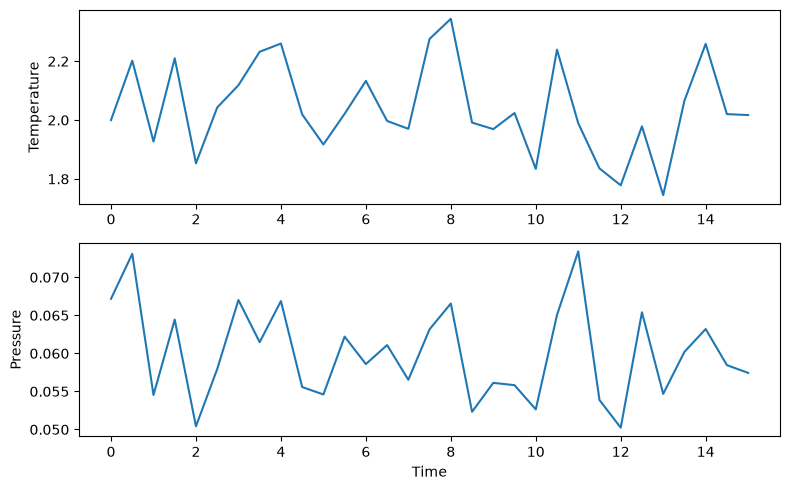

Mean temperature: 2.041
Mean Z: 0.980


In [4]:
data = result.thermo
plt.figure(figsize=(8, 5))
plt.subplot(2, 1, 1)
plt.plot(data.time, data.temperature)
plt.ylabel("Temperature")
plt.subplot(2, 1, 2)
plt.plot(data.time, data.pressure)
plt.ylabel("Pressure")
plt.xlabel("Time")
plt.tight_layout()
plt.show()
print(f"Mean temperature: {result.thermo.temperature.mean():.3f}")
print(f"Mean Z: {result.thermo.compressibility_factor.mean():.3f}")

## Keep the result

The run also exists as `runs/gas` on the machine that executed this notebook.
Later, `Run.load("runs/gas")` reads those files without running MD again.
The players above contain their own sampled trajectory data, so this HTML page
remains interactive even without access to that folder.

## Two species, one set of LJ units

Keep fixed reference units: sigma_ref = epsilon_ref = mass_ref = kB = 1.
B has four times the mass, 1.2 times the LJ size and half the well depth of A.
N is inferred from the counts: 80 + 20 = 100 atoms. Changing these parameters
does not rescale the box or temperature. Colors identify the species, and the
shown radii are half each species' sigma.

Unlike pairs use the Lorentz–Berthelot rule: sigma_AB = (sigma_A + sigma_B)/2 = 1.1,
epsilon_AB = sqrt(epsilon_A * epsilon_B) ≈ 0.707. This is a model choice, not a
universal law. A common cutoff of 2.5 reference length units is used here.


In [5]:
system = Random(
    species={"A": 80, "B": 20},
    rho=.02,
    masses={"A": 1, "B": 4},
    min_distance=1.1,
)
sim = MDSimulation(
    system,
    pair_potential="lj",
    epsilon={"A": 1, "B": .5},
    sigma={"A": 1, "B": 1.2},
    mixing_rule="lorentz-berthelot",
    ensemble="nvt",
    temperature=2,
    timestep=0.005,
    cutoff=2.5,
)
mixture = sim.run(
    steps=3000,
    thermo_every=100,
    trajectory_every=30,
    storage_name="mixture",
)
mixture.view(max_frames=101, projection="perspective")

## Read masses and species directly

At the same equilibrium temperature, heavier particles have lower mean squared
speeds. Inspect one snapshot below; equilibrated time averages are needed for a
quantitative comparison. All atoms still evolve using the same simulation clock.


In [6]:
import numpy as np

atoms = sim.system.atoms
for name in sim.system.species:
    selected = atoms.species == name
    speed = np.linalg.norm(atoms.velocities[selected], axis=1)
    print(f"{name}: {selected.sum()} atoms, mass {atoms.masses[selected][0]:g}, "
          f"mean speed in this snapshot {speed.mean():.3f}")

A: 80 atoms, mass 1, mean speed in this snapshot 2.110
B: 20 atoms, mass 4, mean speed in this snapshot 1.182


## Add a bond explicitly

A diatomic molecule connects two atoms. N now counts molecules: 32 molecules
contain 64 atoms. The harmonic spring acts within each molecule; 12–6 LJ acts
between atoms in different molecules because `exclude_bonded_pairs=True`.

`length` and `stiffness` are separate from sigma and epsilon. To remove bond
vibration while retaining rotation, use `RigidBond(length=.7)` instead.
The default molecular timestep is 0.002; stiffer bonds may need a smaller one.


In [7]:
from fys2160_md import HarmonicBond, RigidBond

molecules = Random(N=32, rho=.01, molecule="diatomic",
                   bond=HarmonicBond(length=.7, stiffness=100))
sim = MDSimulation(
    molecules,
    pair_potential="lj",
    epsilon=1,
    sigma=1,
    exclude_bonded_pairs=True,
    ensemble="nvt",
    temperature=1,
    timestep=0.002,
    cutoff=2.5,
)
bonded = sim.run(
    steps=2000,
    thermo_every=100,
    trajectory_every=20,
    storage_name="bonded",
)
bonded.view(max_frames=101, projection="perspective")

## An air-like mixture with different bonds

Species can have separate bond lengths as well as masses and LJ parameters.
Here 80 N2-like and 20 O2-like molecules contain 200 atoms. The composition and
interaction/bond values are illustrative teaching choices, not a calibrated
model of air. Names are labels; they do not load physical parameters.

Both species share LJ reference units. Masses are per atom: a nitrogen atom is
the mass reference, and an oxygen atom has approximately 16/14 times that mass.
Each molecule's bond remains at its own specified length. The LJ exclusion
applies to the two connected atoms, not to other molecules of the same species.


In [8]:
from fys2160_md import Random, MDSimulation, RigidBond

# Illustrative reduced parameters, not a fitted force field for real air.
air = Random(
    species={"N2": 80, "O2": 20},
    masses={"N2": 1, "O2": 16/14},  # per atom, relative to nitrogen
    molecule="diatomic",
    bond={
        "N2": RigidBond(length=0.65),
        "O2": RigidBond(length=0.75),
    },
    rho=0.01,
    min_distance=1.1,
)
sim = MDSimulation(
    air,
    pair_potential="lj",
    epsilon={"N2": 1, "O2": 0.9},
    sigma={"N2": 1, "O2": 1.05},
    mixing_rule="lorentz-berthelot",
    exclude_bonded_pairs=True,
    ensemble="nvt",
    temperature=2,
    timestep=0.002,
    cutoff=2.5,
)
result = sim.run(
    steps=3000,
    thermo_every=100,
    trajectory_every=30,
    storage_name="air-like",
)
result.view(max_frames=101, projection="perspective")